# Opening-Range Breakout — a quantitative teardown 🔬
### ORB vs a same-exposure random null (paired *t* + permutation *p*) · three null modes · a one-way cost sweep · a planted-persistence positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The decisive object is **not** the ORB return — in a bull tape any net-long rule prints positive — but the **ORB-minus-random** spread at matched exposure. A directional rule must beat its own exposure drawn at random to earn `REAL`; this one doesn't.

> ⚠️ **Not investment advice.** Real data: yfinance QQQ/SPY 5-minute bars, ~60 regular sessions to 2026-06-18 (Yahoo's 5m cap — a short, bull-only sample, named on every axis). The synthetic positive control is deterministic and offline. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opening_range_breakout import data, strategy as st

HAVE_REAL = data.have_real("QQQ")
DAYS = data.build_days("QQQ") if HAVE_REAL else None
print("real QQQ 5m cache present:", HAVE_REAL,
      "| sessions:", (0 if DAYS is None else len(DAYS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'sym': 'QQQ', 'days': 60, 'bars': 78, 'bh_bps': 15.5, 'up_days': 62, 'orb5_matched': [-1.3, 10.1, -11.3, -0.1, -1.32, 48, 0.992], 'orb5_coin': [-1.3, -0.1, -1.2, -0.1, -0.8, 48, 0.552], 'orb5_drift': [-1.3, 8.1, -9.4, -0.1, -0.86, 48, 0.976], 'orb15_matched': [-2.5, 9.7, -12.2, -0.2, -1.78, 45, 0.996], 'orb15_coin': [-2.5, -0.1, -2.3, -0.2, -1.18, 45, 0.601], 'orb15_drift': [-2.5, 7.9, -10.3, -0.2, -0.9, 45, 0.986], 'cost': [(0, -2.5, -12.2, -0.2), (1, -4.5, -14.2, -0.36), (2, -6.5, -16.2, -0.52), (3, -8.5, -18.2, -0.68), (5, -12.5, -22.2, -0.99)], 'breakeven': -6.1, 'syn': [(0.0, 4.1, 2.2, 2.0, 1.72, 0.088), (0.25, 8.3, 0.9, 7.4, 3.0, 0.0), (0.4, 11.8, -0.8, 12.6, 3.64, 0.0)], 'spy': [59, 1.5, -6.5, 0.18, -2.19]}


real QQQ 5m cache present: True | sessions: 60


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | ORB15m daily return -2.5 bps (t vs 0 = -0.20); paired (ORB − matched-random) t = **-1.78**, permutation p = **0.996** — the random entry beats ORB almost surely. SPY agrees. |
| **Tradability** | `MIRAGE` | Break-even one-way cost vs the null = **-6.1 bps** (negative): no spread makes ORB win — it's behind a coin gross. |
| **Beats a coin?** | `BUSTED` | Random same-exposure entry = **+9.7 bps/day** vs ORB **-2.5**. The backtest profit is drift, not the range. |

> 💡 In plain words: strip the day's drift out with a matched-exposure random control and the opening-range break has *negative* marginal information on this tape. The engine would catch a real edge (positive control below); the market just doesn't offer one here.

## 1 · The claim, steelmanned

Let a session have bars $b = 0,\dots,77$ (78 five-minute bars, 09:30–16:00 ET). The opening range over the first $R$ minutes is $[\,\underline{r},\overline{r}\,] = [\min_{b<k} L_b,\ \max_{b<k} H_b\,]$ with $k = R/5$ bars. The first break is the first $b\ge k$ with $C_b>\overline{r}$ (long) or $C_b<\underline{r}$ (short); we enter at the **next** bar's open $O_{b+1}$ (one lag) and exit at the close $C_{77}$. Day return $x_d = s_d\,(C_{77}/O_{b+1}-1)$, $s_d=\pm1$.

- **H₁ (the break carries direction).** $\mathbb{E}[x_d^{\text{ORB}} - x_d^{\text{rand}}] > 0$ against a same-exposure random entry $x_d^{\text{rand}}$.
- **H₂ (it's tradable).** That spread survives one-way costs $c$: break-even $c^\* > $ a realistic spread.

We find **H₁ rejected** (the spread is *negative*) and therefore **H₂ vacuously rejected** ($c^\*<0$). The steelman (Zarattini–Grewal 2023, leveraged + ATR-stopped, multi-year) is out of this short sample's reach — but the *bare* rule fails its own null.

## 2 · So what? — why the null is the whole game

In a sample with mean daily drift $\mu>0$, **any** rule that is net-long a fraction $f$ of the session earns $\approx f\mu$ regardless of *when* it enters. So a positive ORB return is **not** evidence of a signal — it's evidence of exposure. The only identified quantity is the **difference** at matched exposure:

$$\Delta = \mathbb{E}[x^{\text{ORB}}_d - x^{\text{rand}}_d],\qquad x^{\text{rand}}\ \text{holds the same hours, drawn uniformly.}$$

Three nulls bracket the claim: **matched_dir** (same side, random time — isolates *timing*), **coin** (random side + time — isolates timing **and** sign), **drift** (always long — the pure exposure benchmark). A real breakout beats all three; an exposure illusion beats none.

## 3 · How we'd know — the protocol

- **Real tape.** yfinance QQQ (and SPY) 5-minute bars, 60 complete regular sessions to 2026-06-18 (Yahoo's ~60-day 5m cap; bull-only — named on every axis), folded into $(\text{days}, 78, 4)$ OHLC arrays.
- **Signal test.** Paired day-by-day $(x^{\text{ORB}}-x^{\text{rand}})$ t-stat, plus a permutation p of the ORB mean against the distribution of $n{=}2000$ random-entry means. (A directional accuracy *vs its own exposure*, not a raw return.)
- **Pre-registered knobs.** $R\in\{5,15\}$, hold-to-close, **no** stop/target tuning, one execution lag. No search over the headline.
- **Costs.** One-way bps on NAV, twice per round trip; report the break-even one-way cost.
- **Positive control.** A deterministic AR(1)-per-bar day generator plants a known intraday persistence: $\Delta$ must be $>0$ and significant as persistence rises, and $\approx 0$ on a random walk. Machinery proof, never market evidence.
- **What says 'mirage':** $\Delta \le 0$ on the real tape. (It is.)

## 4 · The teardown

### 4a · ORB vs three same-exposure nulls — the spread is negative

ORB daily mean (red) against each random null (green), for the 5- and 15-minute range. The honest controls are **matched_dir** and **drift**; under both, the random entry wins.

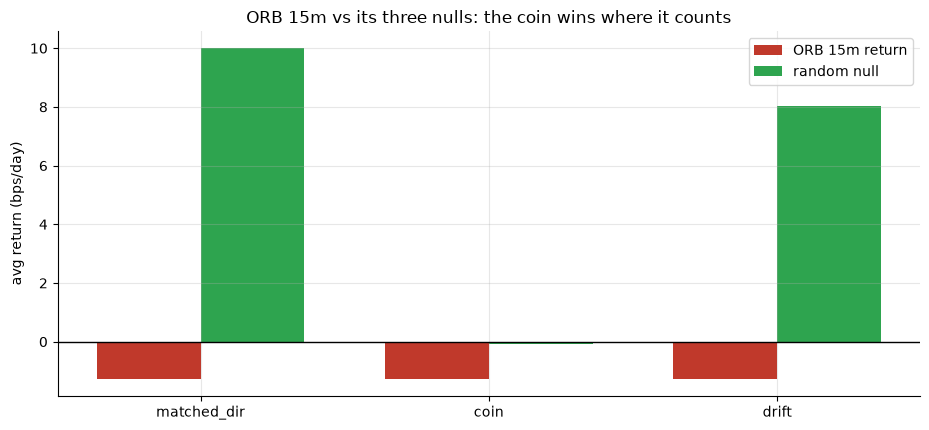

15m matched_dir: ORB  -1.3  null +10.0  edge -11.3
15m coin       : ORB  -1.3  null  -0.1  edge  -1.2
15m drift      : ORB  -1.3  null  +8.0  edge  -9.3


In [2]:
variants = [('ORB 5m','orb5'), ('ORB 15m','orb15')]
modes = ['matched_dir','coin','drift']
rows = {}
for label, key in variants:
    orb_min = 5 if '5m' in label else 15
    for m in modes:
        if HAVE_REAL:
            r = st.evaluate(DAYS, opening_range_min=orb_min, cost_bps=0, null_mode=m, n_iter=1200)
            rows[(label,m)] = (r['orb_mean_bps'], r['null_mean_bps'])
        else:
            v = R[f'{key}_{m}']; rows[(label,m)] = (v[0], v[1])
fig, ax = plt.subplots(figsize=(9.4, 4.4))
x = np.arange(len(modes)); w=.36
ax.bar(x-w/2, [rows[('ORB 15m',m)][0] for m in modes], w, color=RED, label='ORB 15m return')
ax.bar(x+w/2, [rows[('ORB 15m',m)][1] for m in modes], w, color=GREEN, label='random null')
ax.axhline(0,c='k',lw=1); ax.set_xticks(x); ax.set_xticklabels(modes)
ax.set_ylabel('avg return (bps/day)'); ax.set_title('ORB 15m vs its three nulls: the coin wins where it counts'); ax.legend()
plt.tight_layout(); plt.show()
for m in modes: print(f"15m {m:11s}: ORB {rows[('ORB 15m',m)][0]:+5.1f}  null {rows[('ORB 15m',m)][1]:+5.1f}  edge {rows[('ORB 15m',m)][0]-rows[('ORB 15m',m)][1]:+5.1f}")

> 💡 In plain words: against **matched_dir** (same side, random time) ORB runs -12.2 bps/day — a *random clock* beats the breakout by ~12 bps. Against **coin** the gap shrinks (both lose the sign edge), and against **drift** the always-long benchmark crushes ORB by ~10 bps — the rule's profit was the exposure, full stop. H₁ rejected: the break has **negative** marginal information here.

### 4b · Significance — paired t and the permutation null

The paired (ORB − matched-random) t-stat and the ORB return's own t vs zero, for both range lengths and on SPY. Nothing clears 2; the paired t is *negative*.

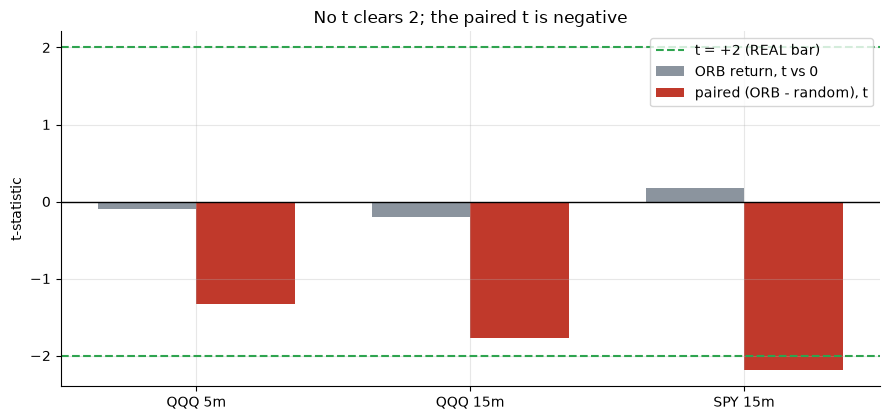

t vs 0 : ['-0.10', '-0.20', '+0.18']
t paired: ['-1.32', '-1.78', '-2.19']


In [3]:
labels, t0s, tps = [], [], []
for orb_min, key in [(5,'orb5_matched'),(15,'orb15_matched')]:
    if HAVE_REAL:
        r = st.evaluate(DAYS, opening_range_min=orb_min, cost_bps=0, null_mode='matched_dir', n_iter=1500)
        t0s.append(r['t_vs_zero']); tps.append(r['t_paired'])
    else:
        t0s.append(R[key][3]); tps.append(R[key][4])
    labels.append(f'QQQ {orb_min}m')
if HAVE_REAL:
    rspy = st.evaluate(data.build_days('SPY'), 15, cost_bps=0, null_mode='matched_dir', n_iter=1500)
    t0s.append(rspy['t_vs_zero']); tps.append(rspy['t_paired'])
else:
    t0s.append(R['spy'][3]); tps.append(R['spy'][4])
labels.append('SPY 15m')
x=np.arange(len(labels)); w=.36; fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.bar(x-w/2, t0s, w, color=GREY, label='ORB return, t vs 0')
ax.bar(x+w/2, tps, w, color=RED, label='paired (ORB - random), t')
ax.axhline(2, ls='--', c=GREEN, label='t = +2 (REAL bar)'); ax.axhline(-2, ls='--', c=GREEN)
ax.axhline(0,c='k',lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('t-statistic'); ax.set_title('No t clears 2; the paired t is negative'); ax.legend()
plt.tight_layout(); plt.show()
print('t vs 0 :', [f'{t:+.2f}' for t in t0s]); print('t paired:', [f'{t:+.2f}' for t in tps])

> 💡 In plain words: the ORB return is statistically a flat line (|t vs 0| ≤ 0.2), and the *paired* test is **negative** (-1.78 at 15m, -2.19 on SPY) — the random entry doesn't just match ORB, it beats it. Permutation p = **0.996**: the random mean exceeds the ORB mean in ~99.6% of resamples. There is no $R$, ticker, or sign convention here that rescues H₁.

### 4c · Costs — the break-even is negative

ORB net daily return as one-way cost rises. Because the gross spread over the null is already negative, the break-even one-way cost is **below zero** — no real spread can help.

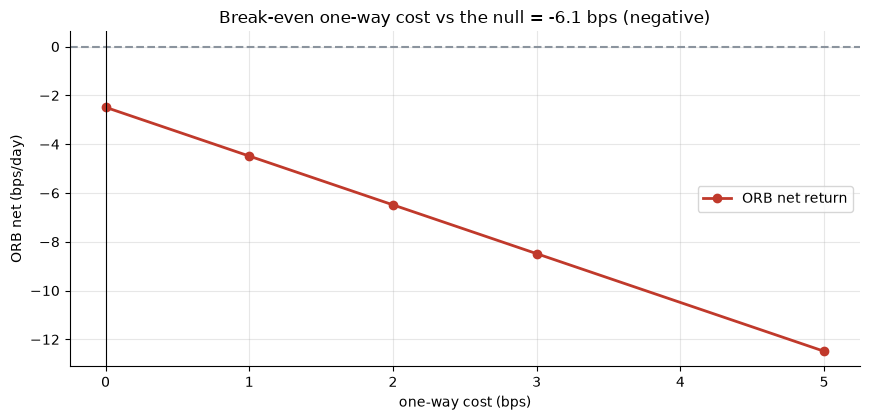

net by cost: [(0, -2.5), (1, -4.5), (2, -6.5), (3, -8.5), (5, -12.5)]  break-even: -6.1 bps


In [4]:
costs = [c[0] for c in R['cost']]
if HAVE_REAL:
    nets = [st.evaluate(DAYS, 15, cost_bps=c, null_mode='matched_dir', n_iter=500)['orb_mean_bps'] for c in costs]
    be = st.breakeven_cost(DAYS, 15, null_mode='matched_dir')
else:
    nets = [c[1] for c in R['cost']]; be = R['breakeven']
fig, ax = plt.subplots(figsize=(8.8,4.3))
ax.plot(costs, nets, 'o-', c=RED, lw=2, label='ORB net return')
ax.axhline(0, ls='--', c=GREY); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('ORB net (bps/day)')
ax.set_title(f'Break-even one-way cost vs the null = {be:+.1f} bps (negative)'); ax.legend()
plt.tight_layout(); plt.show()
print('net by cost:', list(zip(costs,[round(n,1) for n in nets])), ' break-even:', round(be,1),'bps')

> 💡 In plain words: a negative break-even cost is the cleanest possible statement of 'no edge' — you would need to be *paid* the spread for ORB to match a coin. Real QQQ/SPY spreads are ~0.5–1 bp each way; every one of them pushes the rule further underwater.

### 4d · Faithful-engine control — plant a breakout edge, the test finds it

On a deterministic AR(1)-per-bar tape, persistence $\rho$ makes a range break genuinely tend to continue. The measured ORB-minus-random edge must be $\approx0$ at $\rho=0$ and rise, significantly, with $\rho$:

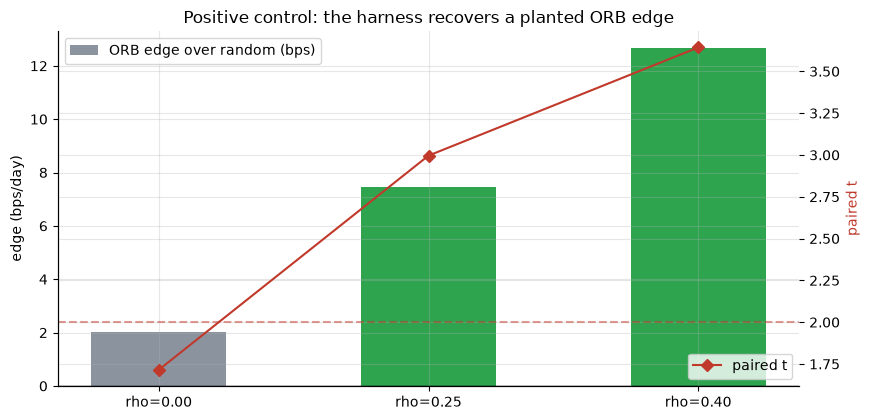

rho=0.00: edge   +2.0 bps  paired t +1.72
rho=0.25: edge   +7.5 bps  paired t +3.00
rho=0.40: edge  +12.7 bps  paired t +3.64


In [5]:
pers = [s[0] for s in R['syn']]
edges, tps_s = [], []
for p in pers:
    S = data.synthetic_days(n_days=800, persistence=p, seed=352)
    r = st.evaluate(S, 15, cost_bps=0, null_mode='matched_dir', n_iter=1000)
    edges.append(r['edge_bps']); tps_s.append(r['t_paired'])
fig, ax = plt.subplots(figsize=(8.8,4.3))
x=np.arange(len(pers))
ax.bar(x, edges, .5, color=[GREY,GREEN,GREEN], label='ORB edge over random (bps)')
ax2=ax.twinx(); ax2.plot(x, tps_s, 'D-', c=RED, label='paired t'); ax2.axhline(2, ls='--', c=RED, alpha=.5)
ax.set_xticks(x); ax.set_xticklabels([f'rho={p:.2f}' for p in pers])
ax.set_ylabel('edge (bps/day)'); ax2.set_ylabel('paired t', color=RED)
ax.set_title('Positive control: the harness recovers a planted ORB edge'); ax.axhline(0,c='k',lw=1)
ax.legend(loc='upper left'); ax2.legend(loc='lower right')
plt.tight_layout(); plt.show()
for p,e,t in zip(pers,edges,tps_s): print(f'rho={p:.2f}: edge {e:+6.1f} bps  paired t {t:+.2f}')

> 💡 In plain words: plant a real opening-range edge and the test banks it — edge climbs from ~0 at $\rho{=}0$ to +12.6 bps at $\rho{=}0.40$ with paired t = +3.64 (p≈0). The harness can detect the effect it's accused of missing; the real tape simply has none. (This is a **machinery** proof — a synthetic Sharpe is never market evidence.)

## 5 · The verdict

- **Signal `NONE`** — ORB15m -2.5 bps (t vs 0 = -0.20); paired vs matched-random t = **-1.78**, permutation p = **0.996**; SPY paired t = -2.19. The break has negative marginal information; H₁ rejected.
- **Tradability `MIRAGE`** — break-even one-way cost = **-6.1 bps** (negative). Behind a coin gross, a loser net of any spread.
- **Beats a coin? `BUSTED`** — random same-exposure entry +9.7 bps vs ORB -2.5. The 'edge' was exposure to a bull drift, captured *better* by a dart than by the rule.

## 6 · Could you trade it? — the honest scope

The bare rule is a non-starter: negative gross spread, negative break-even cost. The only live question is whether the *engineered* version — leverage + ATR stop/target, the Zarattini–Grewal recipe — adds something our 60-day, no-stop test can't see. We can frame the bound: even granting ORB the random null's exposure return, the **stop/target** would have to manufacture the entire edge, since the *entry* contributes nothing positive here.

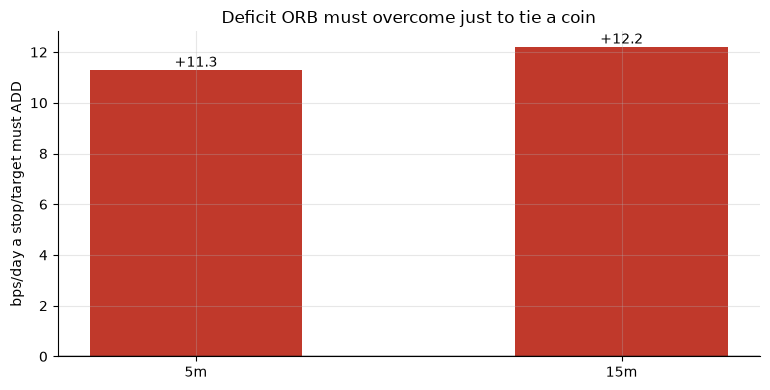

bps the overlay must add to break even vs random: {'5m': 11.3, '15m': 12.2}


In [6]:
# What the rule would need: the gap ORB must close just to MATCH a coin, by range length
gaps = {}
for orb_min, key in [(5,'orb5_matched'),(15,'orb15_matched')]:
    if HAVE_REAL:
        r = st.evaluate(DAYS, orb_min, cost_bps=0, null_mode='matched_dir', n_iter=1200)
        gaps[f'{orb_min}m'] = -r['edge_bps']
    else:
        gaps[f'{orb_min}m'] = -R[key][2]
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.bar(list(gaps), list(gaps.values()), color=RED, width=.5)
ax.set_ylabel('bps/day a stop/target must ADD'); ax.axhline(0,c='k',lw=1)
ax.set_title('Deficit ORB must overcome just to tie a coin')
for i,(k,v) in enumerate(gaps.items()): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('bps the overlay must add to break even vs random:', {k:round(v,1) for k,v in gaps.items()})

> 💡 In plain words: a stop/target/leverage overlay would have to add ~10–12 bps/day *net of its own costs* just to drag the entry up to a coin — before any actual edge. That's a tall order for risk management alone, and it's exactly where the burden of proof sits for the engineered ORB. On the *bare* rule the answer to 'could you trade it?' is a clean **no**.

## 7 · Going further

- **Re-run the steelman in full.** Add ATR stops, a target multiple, and leverage (Zarattini–Grewal 2023) and re-measure the paired spread — is the alpha the *range* or the *overlay*? The harness and null are parameterised for it.
- **Regime split.** Yahoo's 60-day cap forces a bull-only window; a deeper intraday feed lets you test the drift confound in a down-market, where the always-long null inverts.
- **Intraday-momentum done right.** Gao et al. (2018) first-30m→last-30m is a *different, real* object; contrast it with the ORB to see why one survives a null and the other doesn't.

*The reproducible core is offline and deterministic; the real tape is yfinance public data. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*